In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
# uncomment the following line if using colab
# %pip install lmfit
import lmfit

Physical constants assuming electron in the box

In [2]:
h = 6.626E-34 # kgm^2/s  (Planck's Constant)
m = 9.11E-31 # kg  (mass of an electron)
c = 3.00E8 # m/s (speed of light)

For each dye molecule, the required values are $\lambda_\text{max}$ in nm and the number of π-electrons in the conjugated chain. For testing, you can use the sample data for the 4,4'-cyanine series (Moog, 1991) provided in the code cell.

The output includes the length of the box, $L$, corresponding to that wavelength based on the equation

$$\lambda_\text{max} = {{8mcL^2}\over{h(N+1)}}$$

where $N$ is the number of π-electrons in the chain. Note that the various analyses may use number of electrons, number of electron pairs, number of bonds, or number of carbon atoms in the chain, but all of those are simply related to each other as shown in the code cell.


In [3]:
# Replace the following arrays with student data
wavelengths = np.array([592, 708, 813, 929])
electrons = np.array([10, 12, 14, 16])

# Uncomment the following lines to allow student input of data
# nmolecules = input("Enter the number of molecules: ")
# wavelengthlist = []
# electronlist = []
# for i in range(int(nmolecules)):
#     wavelengthlist.append(float(input("Enter the wavelength (nm) of molecule " + str(i+1) + ": ")))
#     electronlist.append(float(input("Enter the number of π-electrons in molecule " + str(i+1) + ": ")))
# wavelengths = np.array(wavelengthlist)
# electrons = np.array(electronlist)

wavelengthnm = wavelengths * 1.e-9
bonds = electrons - 2
carbons = electrons - 3
electronpairs = electrons / 2
boxlength = np.sqrt(h * wavelengthnm * (electrons + 1) /(8 * m * c))
DE = h * c / wavelengthnm
df = pd.DataFrame({'wavelength (nm)': wavelengths, 'bonds': bonds, 'electrons': electrons, 'carbons': carbons, 'electron pairs': electronpairs, 'box length (m)': boxlength,
                   '∆E (J)': DE})
pd.set_option('display.precision', 2)
display(df)


,wavelength (nm),bonds,electrons,carbons,electron pairs,box length (m),∆E (J)
0,592,8,10,7,5.0,1.40e-09,3.36e-19
1,708,10,12,9,6.0,1.67e-09,2.81e-19
2,813,12,14,11,7.0,1.92e-09,2.45e-19
3,929,14,16,13,8.0,2.19e-09,2.14e-19


The following cells calculate the fit from Moog, *J. Chem. Educ.*, 1991. The two parameter fit is for the average bondlength in the conjugated chain and a paramter, $\gamma$, that represents the additional length due to the polarizability at the ends of the chain.

$$L = (b \times l) + \gamma$$

where $b$ and $L$ are the number of bonds calculated box length for each dye, $l$ is the average bondlength, and $\gamma$ is the additional length.

### Moog fit using polyfit

polyfit is a numpy function that fits data to a polynomial. We'll use four arguments here:

* independent variable
* dependent variable
* polynomial degree
* `cov=True`, which returns a covariance matrix from which uncertainties can be calculated

polyfit then returns an array. Index 0 is an array containing the slope and intercept; index 1 is a 2x2 matrix with the squared uncertainties as the diagonal elements.


In [4]:
# For the Moog fit, the number of bonds is the independent variable
# and the box length is the dependent variable.
fitMoogresults = np.polyfit(bonds, boxlength, 1, cov=True)

# Extract the slope (b) and intercept (γ) from the fit results, along with their uncertainties.
print("b: ", f"{fitMoogresults[0][0]:.2e} ± {np.sqrt(fitMoogresults[1][0][0]):.2e} m")
print("γ: ", f"{fitMoogresults[0][1]:.2e} ± {np.sqrt(fitMoogresults[1][1][1]):.2e} m")

# corrcoef is a separate function that can be used to calculate the R^2 value
print("R^2: ", f"{np.corrcoef(bonds, boxlength)[0, 1]**2:.2f}")

b:  1.30e-10 ± 9.19e-13 m
γ:  3.66e-10 ± 1.03e-11 m
R^2:  1.00


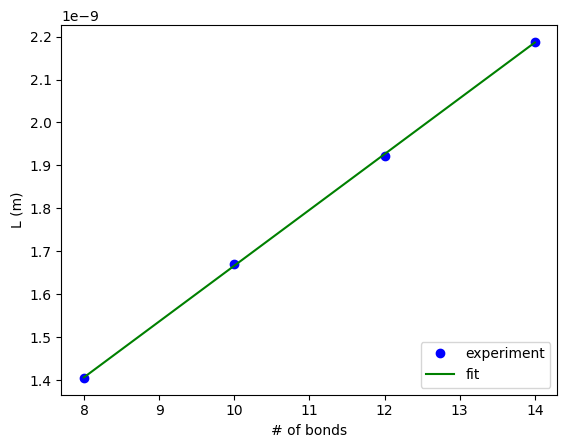

In [5]:
# check fit with plot

bondlength = fitMoogresults[0][0]
gamma = fitMoogresults[0][1]
Lfit = bondlength * bonds + gamma

plt.plot(bonds, boxlength, marker='o', linestyle='', color='b')    # original data
plt.plot(bonds, Lfit,  marker='', linestyle='-', color='g')                # fit results
plt.xlabel("# of bonds")
plt.ylabel("L (m)")
plt.legend(['experiment', 'fit'], loc='lower right')

### Moog fit using lmfit

The lmfit package provides fitting to non-linear (and linear) functions. The approach is minimization of the sum of the squared residuals between the data and the fit.

We'll first work through the method using the Moog linear fit as an example (which we hope will give the same result as what we've already done).

First, we create a `Parameters` object, which is a dictionary of parameters. Each parameter has a name (or key) and an initial value. For the Moog fit, the two parameters are the bondlength and the additional length, $\gamma$.

In [6]:
params_Moog = lmfit.Parameters()
params_Moog.add('bondlength', value = 1.39e-10)
params_Moog.add('gamma', value = 0.5)

We then declare a function that returns an array of residuals for our data based on the Moog model. The function takes the following three arguments: The `Parameters` object, the independent variable data (number of bonds) and the dependent variable data (box length).

In [7]:
def fit_Moog(params, bonds, boxlength):
    # calculate the boxlength the model predicts for the current parameter values
    Lcalc = params['bondlength'] * bonds + params['gamma'] 
    # calculate the residuals (difference between model and data)
    residuals = boxlength - Lcalc
    return residuals

Now we're ready to invoke the minimize function of lmfit. For that, we need three arguments:

* The function that returns the residuals for our model
* The `Parameters` object
* An array that contains the independent and dependent variable data.

lmfit.minimize returns a complex object from which we can extract the optimized values of the parameters (through the `params` attributes) as well as the uncertainties from the covariance matrix (through the `covar` attribute). See the code cell for the syntax.

In [8]:
resultMoog = lmfit.minimize(fit_Moog, params_Moog, args=(bonds, boxlength))

# Show everything that the fit provides
print(lmfit.fit_report(resultMoog))
print()

# Extract the parameter values and uncertainties
print("The average bondlength is", f"{resultMoog.params.valuesdict()['bondlength']:.2e} ± {np.sqrt(resultMoog.covar[0, 0]):.2e}", "m")
print("The value of γ is", f"{resultMoog.params.valuesdict()['gamma']:.2e} ± {np.sqrt(resultMoog.covar[1, 1]):.2e}", "m")

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 10
    # data points      = 4
    # variables        = 2
    chi-square         = 3.3765e-23
    reduced chi-square = 1.6883e-23
    Akaike info crit   = -208.515605
    Bayesian info crit = -209.743016
[[Variables]]
    bondlength:  1.3005e-10 +/- 9.1877e-13 (0.71%) (init = 1.39e-10)
    gamma:       3.6569e-10 +/- 1.0313e-11 (2.82%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(bondlength, gamma) = -0.9800

The average bondlength is 1.30e-10 ± 9.19e-13 m
The value of γ is 3.66e-10 ± 1.03e-11 m


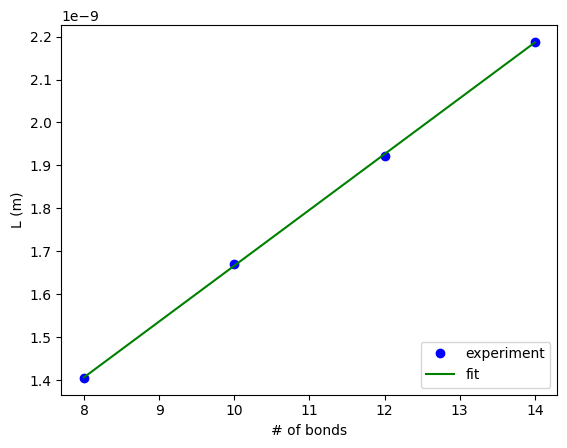

In [9]:
# check fit with plot

bondlength = resultMoog.params.valuesdict()['bondlength']
gamma = resultMoog.params.valuesdict()['gamma']
Lfit = bondlength * bonds + gamma
# plot fit

plt.plot(bonds, boxlength, marker='o', linestyle='', color='b')    # original data
plt.plot(bonds, Lfit,  marker='', linestyle='-', color='g')                # fit results
plt.xlabel("# of bonds")
plt.ylabel("L (m)")
plt.legend(['experiment', 'fit'], loc='lower right')

### Shoemaker-Garland-Kuhn fit using lmfit

Shoemaker and Garland propose a fit based on Kuhn's original work on these conjugated dye systems. That fit also has two parameters: the bondlength $l$, and a parameter $\alpha$ that represents the fractional number of additional heavy atoms in the conjugated chain to represent the polarizability. The equation for the Shoemaker-Garland fit is

$$\lambda_\text{max} = {{8mcl^2}\over{h}} {{(p + 3 +\alpha)^2}\over{p+4}}$$

where $p$ is the number of carbon atoms in the conjugated chain.

In the following cells, we'll apply lmfit to find the optimized values of $l$ and $\alpha$.

In [10]:
# Create the Parameters object with the two parameters. Shoemaker and Garland suggest that
# the value of alpha should be in the range [0.5, 1].

params_Kuhn = lmfit.Parameters()
params_Kuhn.add('bondlength', value = 1.39e-10)
params_Kuhn.add('alpha', value = 1)

In [11]:
# Define the function that returns the residuals for the Shoemaker-Garland model.

def fit_Kuhn(params, p, lambdaobs):
    lambdacalc = 8 * m * c * params['bondlength']**2 * (p + 3 + params['alpha'])**2 / (h * (p + 4))
    resid = lambdaobs - lambdacalc
    return resid

In [12]:
# Apply lmfit.minimize to optimize the parameter values

resultKuhn = lmfit.minimize(fit_Kuhn, params_Kuhn, args=(carbons, wavelengthnm))

print(lmfit.fit_report(resultKuhn))
print()
print("The average bondlength is", f"{resultKuhn.params.valuesdict()['bondlength']:.2e} ± {np.sqrt(resultKuhn.covar[0, 0]):.2e}", "m")
print("The value of α is", f"{resultKuhn.params.valuesdict()['alpha']:.2f} ± {np.sqrt(resultKuhn.covar[1, 1]):.2f}")

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 4
    # variables        = 2
    chi-square         = 2.4206e-17
    reduced chi-square = 1.2103e-17
    Akaike info crit   = -154.584943
    Bayesian info crit = -155.812354
[[Variables]]
    bondlength:  1.3005e-10 +/- 9.1925e-13 (0.71%) (init = 1.39e-10)
    alpha:       0.81196102 +/- 0.09896935 (12.19%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(bondlength, alpha) = -0.9872

The average bondlength is 1.30e-10 ± 9.19e-13 m
The value of α is 0.81 ± 0.10


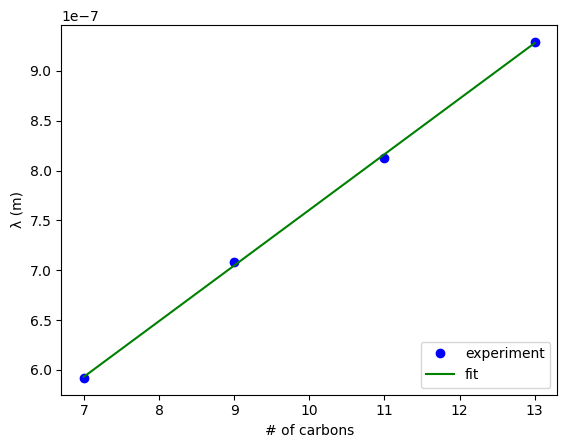

In [13]:
# check fit with plot

bonds = resultKuhn.params.valuesdict()['bondlength']
alpha = resultKuhn.params.valuesdict()['alpha']
lambdaFit = 8 * m * c * bonds**2 * (carbons + 3 + alpha)**2 / (h * (carbons + 4))
# plot fit

plt.plot(carbons, wavelengthnm, marker='o', linestyle='', color='b')    # original data
plt.plot(carbons, lambdaFit,  marker='', linestyle='-', color='g')      # fit results
plt.xlabel("# of carbons")
plt.ylabel("λ (m)")
plt.legend(['experiment', 'fit'], loc='lower right')